In [1]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

here = Path.cwd().resolve()
ROOT = next((p for p in [here, *here.parents]
             if (p / 'README.md').exists() and (p / 'notebooks').exists()), None)
if ROOT is None:
    raise FileNotFoundError('未找到项目根目录，请从仓库内运行 Notebook。')
env_file = ROOT / '.env'
if not env_file.exists():
    raise FileNotFoundError('缺少 .env：请复制 .env.example 并填写本机数据库信息。')
load_dotenv(env_file)
required = ['MYSQL_USER', 'MYSQL_PWD', 'MYSQL_HOST', 'MYSQL_DB']
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'.env 缺少配置项：{missing}')
DASHBOARD_DIR = ROOT / 'dashboard' / '02'
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
db = URL.create("mysql+pymysql",
    username=os.getenv("MYSQL_USER"), password=os.getenv("MYSQL_PWD"),
    host=os.getenv("MYSQL_HOST"), port=int(os.getenv("MYSQL_PORT", 3306)),
    database=os.getenv("MYSQL_DB"), query={"charset": "utf8mb4"})
engine = create_engine(db)
print('本地配置已加载，数据库连接已创建。')

本地配置已加载，数据库连接已创建。


    shipping_mode  valid_rows  late_rows  late_rate  share_of_late   late_gmv
0  Standard Class      103153    41023.0       39.8           41.4  8364603.0
1    Second Class       33806    26987.0       79.8           27.3  5477446.0
2     First Class       26513    26513.0      100.0           26.8  5408069.0
3        Same Day        9293     4454.0       47.9            4.5   876277.0


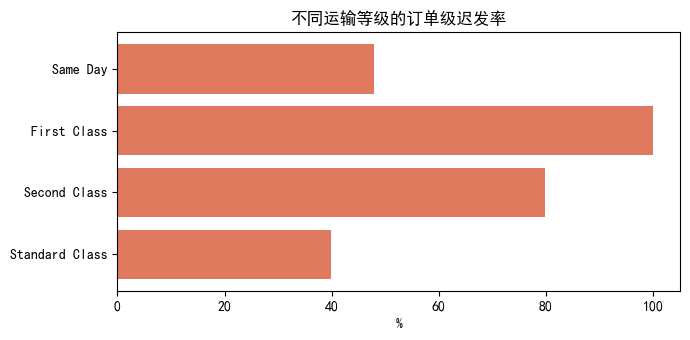

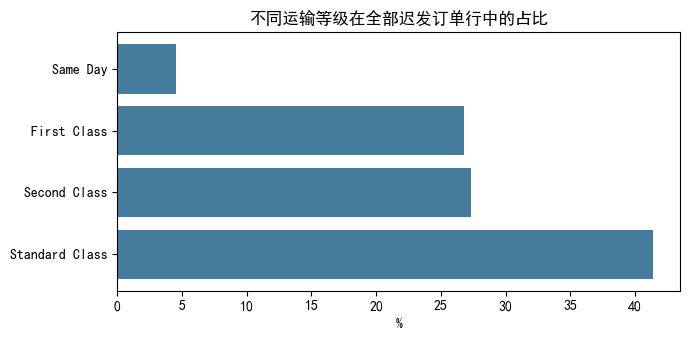

In [2]:
sql_mode = """
SELECT shipping_mode,
       COUNT(*)                                        AS valid_rows,
       SUM(late_delivery_risk)                         AS late_rows,
       ROUND(SUM(late_delivery_risk)/COUNT(*)*100,1)   AS late_rate,
       ROUND(SUM(late_delivery_risk)/98977*100,1)      AS share_of_late,   -- 占全部迟发的量
       ROUND(SUM(CASE WHEN late_delivery_risk=1 THEN sales END),0) AS late_gmv
FROM fact_order_item
WHERE delivery_status <> 'Shipping canceled'
GROUP BY shipping_mode
ORDER BY late_rows DESC
"""
mode = pd.read_sql(sql_mode, engine)
print(mode)

# 分别输出订单级迟发率与迟发订单行占比
charts = [
    ('late_rate', '不同运输等级的订单级迟发率', '#e07a5f', '不同等级迟发率.png'),
    ('share_of_late', '不同运输等级在全部迟发订单行中的占比', '#457b9d', '不同等级迟发量占比.png'),
]
for column, title, color, filename in charts:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(mode['shipping_mode'], mode[column], color=color)
    ax.set_title(title)
    ax.set_xlabel('%')
    fig.tight_layout()
    fig.savefig(DASHBOARD_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()

In [3]:
sql_pareto = """
WITH combo AS (                       -- ① 按三维组合聚合迟发行数与GMV
  SELECT f.shipping_mode, f.market, p.category_name,
         SUM(f.late_delivery_risk) AS late_rows,
         SUM(CASE WHEN f.late_delivery_risk=1 THEN f.sales END) AS late_gmv
  FROM fact_order_item f
  JOIN dim_product p ON f.product_card_id = p.product_card_id
  WHERE f.delivery_status <> 'Shipping canceled'
  GROUP BY f.shipping_mode, f.market, p.category_name
)
SELECT shipping_mode, market, category_name, late_rows, late_gmv,
       ROUND(SUM(late_rows) OVER (ORDER BY late_rows DESC)
             / SUM(late_rows) OVER () * 100, 1) AS cum_pct   -- ② 滚雪球累计占比
FROM combo
ORDER BY late_rows DESC
"""
pareto = pd.read_sql(sql_pareto, engine)
print("组合总数:", len(pareto))
n50 = int(pareto['cum_pct'].ge(50).idxmax() + 1)  # 第一个累计占比达到50%的组合排名
n80 = int(pareto['cum_pct'].ge(80).idxmax() + 1)  # 第一个累计占比达到80%的组合排名
print("覆盖约50%迟发订单行的组合数:", n50)
print("覆盖约80%迟发订单行的组合数:", n80)
pareto.head(10)          # 看看头部组合都是谁

组合总数: 639
覆盖约50%迟发订单行的组合数: 52
覆盖约80%迟发订单行的组合数: 117


,shipping_mode,market,category_name,late_rows,late_gmv,cum_pct
0,Standard Class,LATAM,Cleats,1630.0,293891.018248,1.6
1,Standard Class,Europe,Cleats,1503.0,274034.727451,3.2
2,Standard Class,LATAM,Men's Footwear,1480.0,192385.208140,4.7
3,Standard Class,LATAM,Women's Apparel,1415.0,211150.000000,6.1
4,Standard Class,LATAM,Indoor/Outdoor Games,1393.0,211765.258121,7.5
5,Standard Class,Europe,Men's Footwear,1357.0,176396.437464,8.9
6,Standard Class,Europe,Women's Apparel,1336.0,204400.000000,10.2
7,Standard Class,Pacific Asia,Cleats,1212.0,218543.576211,11.4
8,Standard Class,Europe,Indoor/Outdoor Games,1196.0,177978.778438,12.7
9,Standard Class,LATAM,Fishing,1185.0,473976.313035,13.8


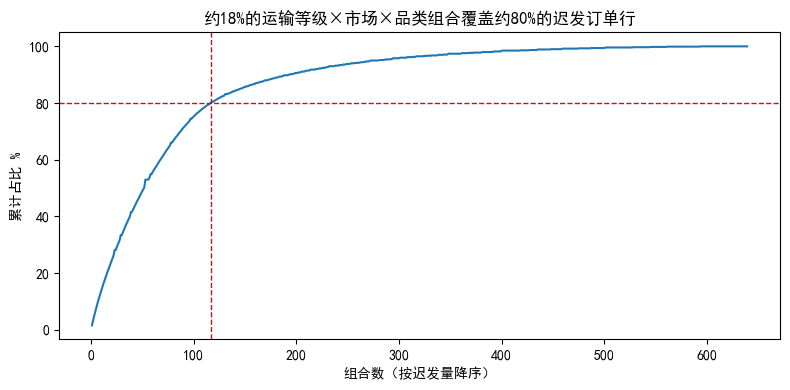

迟发受影响 GMV 合计 ≈ 2013 万


In [4]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pareto)+1), pareto['cum_pct'])
plt.axhline(80, color='#c1121f', ls='--', lw=1)
plt.axvline(n80, color='#c1121f', ls='--', lw=1)
plt.title(f'约{n80/len(pareto)*100:.0f}%的运输等级×市场×品类组合覆盖约80%的迟发订单行')
plt.xlabel('组合数（按迟发量降序）'); plt.ylabel('累计占比 %')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '迟发帕累托.png', dpi=200, bbox_inches='tight')
plt.show()

total_late_gmv = pareto['late_gmv'].sum()
print(f"迟发受影响 GMV 合计 ≈ {total_late_gmv/1e4:.0f} 万")

In [5]:
# 读订单级数据（履约属性在订单内唯一，DISTINCT 取一行；排除取消单）
orders = pd.read_sql("""
    SELECT DISTINCT order_id, shipping_mode,
           days_for_shipping_real      AS real_days,
           days_for_shipment_scheduled AS sched_days
    FROM fact_order_item
    WHERE delivery_status <> 'Shipping canceled'
""", engine)

# 当前迟发标记：实际 > 承诺
orders['late_now'] = (orders['real_days'] > orders['sched_days']).astype(int)

# 情景A：把承诺天数校准成各等级"实际能达到"的天数
new_promise = {'Same Day': 1, 'First Class': 2, 'Second Class': 4, 'Standard Class': 4}
orders['new_sched'] = orders['shipping_mode'].map(new_promise)
orders['late_A'] = (orders['real_days'] > orders['new_sched']).astype(int)   # 用新承诺重判

r_now, r_A = orders['late_now'].mean(), orders['late_A'].mean()
print(f"当前迟发率:  {r_now*100:.1f}%")
print(f"情景A迟发率: {r_A*100:.1f}%")
print(f"降幅:        {(r_now - r_A)*100:.1f} 个百分点")

当前迟发率:  57.3%
情景A迟发率: 31.6%
降幅:        25.7 个百分点


    shipping_mode    订单数  当前迟发率  情景A迟发率    问题类型
0     First Class   9602  100.0     0.0  承诺口径差异
1        Same Day   3407   48.4     0.0  承诺口径差异
2    Second Class  12256   80.0    40.0  履约能力差异
3  Standard Class  37632   39.8    39.8  履约能力差异


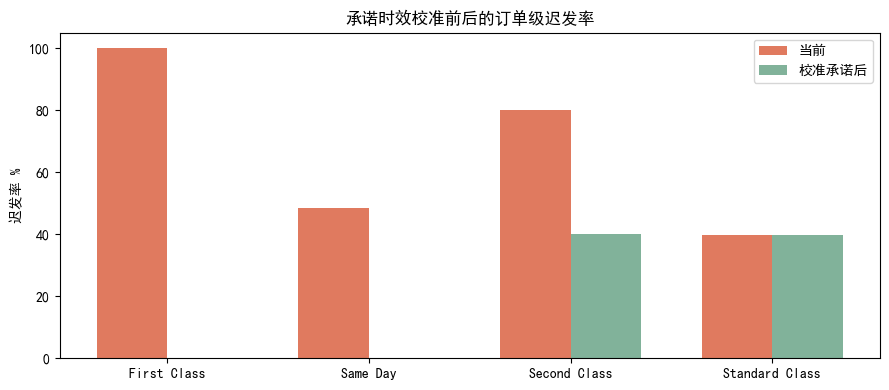

In [6]:
by_mode = orders.groupby('shipping_mode').agg(
    订单数=('order_id', 'size'),
    当前迟发率=('late_now', 'mean'),
    情景A迟发率=('late_A', 'mean')).reset_index()
by_mode['当前迟发率'] = (by_mode['当前迟发率'] * 100).round(1)
by_mode['情景A迟发率'] = (by_mode['情景A迟发率'] * 100).round(1)
# 校准承诺后低于10%归为承诺口径差异，否则归为履约能力差异
by_mode['问题类型'] = by_mode['情景A迟发率'].apply(
    lambda x: '承诺口径差异' if x < 10 else '履约能力差异')
print(by_mode)

# 前后对比条形图
import numpy as np
x = np.arange(len(by_mode)); w = 0.35
plt.figure(figsize=(9, 4))
plt.bar(x - w/2, by_mode['当前迟发率'], w, label='当前', color='#e07a5f')
plt.bar(x + w/2, by_mode['情景A迟发率'], w, label='校准承诺后', color='#81b29a')
plt.xticks(x, by_mode['shipping_mode']); plt.ylabel('迟发率 %')
plt.title('承诺时效校准前后的订单级迟发率')
plt.legend(); plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '校准承诺前后迟发率.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# GMV 是行级（可加），读全部行；real/sched/等级 在订单内恒定，行级判定等价
rows = pd.read_sql("""
    SELECT shipping_mode, sales,
           days_for_shipping_real      AS real_days,
           days_for_shipment_scheduled AS sched_days
    FROM fact_order_item
    WHERE delivery_status <> 'Shipping canceled'
""", engine)
rows['new_sched'] = rows['shipping_mode'].map(new_promise)   # 复用 Cell 5 的映射

gmv_now = rows.loc[rows['real_days'] > rows['sched_days'], 'sales'].sum()
gmv_A   = rows.loc[rows['real_days'] > rows['new_sched'],  'sales'].sum()
print(f"当前受影响 GMV:   {gmv_now/1e4:.0f} 万")
print(f"情景A受影响 GMV:  {gmv_A/1e4:.0f} 万")
print(f"可从'受影响'转为'准时'的 GMV: {(gmv_now - gmv_A)/1e4:.0f} 万")

当前受影响 GMV:   2013 万
情景A受影响 GMV:  1111 万
可从'受影响'转为'准时'的 GMV: 901 万


### 情景测算假设与限制
1. 历史实际配送天数保持不变，仅调整承诺天数并重新判定迟发；该测算不包含承诺变化可能引起的客户行为变化。
2. 情景A评估承诺口径校准的统计影响，不代表实际配送速度发生变化。
3. 数据集不包含罚金和客户流失字段，受影响 GMV 表示迟发覆盖的交易规模，不等同于直接损失。
4. Standard Class 和 Second Class 在承诺校准后仍存在约31.6%的订单级迟发，需要通过履约能力改善解决。

In [8]:
# 情景阶梯：承诺定在不同分位，迟发率怎么变
scenarios = {
    '现状':   {'Same Day':0, 'First Class':1, 'Second Class':2, 'Standard Class':4},
    '情景A(平均)': {'Same Day':1, 'First Class':2, 'Second Class':4, 'Standard Class':4},
    '情景B(P80)':  {'Same Day':1, 'First Class':2, 'Second Class':5, 'Standard Class':5},
    '情景C(全覆盖)':{'Same Day':1, 'First Class':2, 'Second Class':6, 'Standard Class':6},
}
for name, promise in scenarios.items():
    late = (orders['real_days'] > orders['shipping_mode'].map(promise)).mean()
    print(f"{name:14s} 迟发率 {late*100:5.1f}%")

现状             迟发率  57.3%
情景A(平均)        迟发率  31.6%
情景B(P80)       迟发率  15.9%
情景C(全覆盖)       迟发率   0.0%
